In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = False

#day = datetime.today().strftime('%Y-%m-%d')
day = '2025-03-25' #'2024-10-22'
sample =  'all' # 'randomsample500' 

In [2]:
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import statsmodels.graphics.api as smg
import statsmodels.api as sm

## Read timeseries stats

In [3]:
metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_{sample}_2024-11-26.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_{sample}_{day}.csv", index_col=0)
print("number of time series:", len(ts_stats))
print("number of metadata:", len(metadata))
print("number of fit parameter sets:", len(params))

number of time series: 5547
number of metadata: 203
number of fit parameter sets: 49923


In [4]:
# get other metadata from timeseries file
ts = pd.read_csv('data/HATCH_v1.5_clean.csv')
ts_metadata = ts[['ID', 'Spatial Scale', 'Region', 'Country Name', 'Technology Name',
       'Metric', 'Unit', 'Data Source', 'Variable']]

In [5]:
params = params.loc[params['fit_success']]
metadata['Technology Name'] = metadata.index

In [6]:
# 'technology' and 'tech_name' are unique identifiers for each time series,
# while 'Technology Name' is a field which gives the technology, for which several time series for different countries can exist

full_table = pd.merge(params, ts_stats.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'tech_name')
print(len(full_table))
full_table = pd.merge(full_table, ts_metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'ID')
print(len(full_table))
full_table = pd.merge(full_table, metadata, how = 'left', left_on = 'Technology Name', right_on='Technology Name')
print(len(full_table))
# there seem to be duplicate matches, which need to be removed
full_table = full_table.drop_duplicates(subset=params.columns)
print(len(full_table))
#full_table

49870
49870
56322
49870


In [7]:
# correct internally inconsistent labels
full_table['Metric'] = full_table['Metric'].replace({'Annual production': 'Annual Production',
                                                     'Cumulative total capacity': 'Cumulative Total Capacity'})

In [8]:
full_table.columns

Index(['functional_form', 'fit_procedure', 'fit_success', 'r_squared',
       'adj_r_squared', 'MCp', 'BIC', 'MAPE', 'a', 'b', 'c', 'a_std', 'b_std',
       'c_std', 'fit_message', 'int_flat', 'technology', 'Technology Name',
       'd', 'd_std', 'error_type', 'error_msg', 'n', 't_min', 't_max',
       'dt_min', 'dt_max', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first', 'tech_name', 'ID',
       'Spatial Scale', 'Region', 'Country Name', 'Metric', 'Unit',
       'Data Source', 'Variable', 'Material Use Numeric

In [9]:
# mask r_squared values outside of range
full_table['r_squared_masked'] = full_table['r_squared'].mask(full_table['r_squared'] < 0).mask(full_table['r_squared'] > 1)
full_table['adj_r_squared_masked'] = full_table['adj_r_squared'].mask(full_table['adj_r_squared'] < 0).mask(full_table['adj_r_squared'] > 1)

In [10]:
pd.options.display.float_format = '{:.2f}'.format

In [11]:
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
full_table['metric_grouped'] = full_table['Metric'].map(group_metrics)

## Test distribution of outcome variable

array([[<Axes: title={'center': 'bass'}>,
        <Axes: title={'center': 'bertalanffy'}>,
        <Axes: title={'center': 'exponential'}>],
       [<Axes: title={'center': 'gompertz'}>,
        <Axes: title={'center': 'linear'}>,
        <Axes: title={'center': 'logistic'}>],
       [<Axes: title={'center': 'logistic-linear-cont'}>,
        <Axes: title={'center': 'richards'}>,
        <Axes: title={'center': 'softplus'}>]], dtype=object)

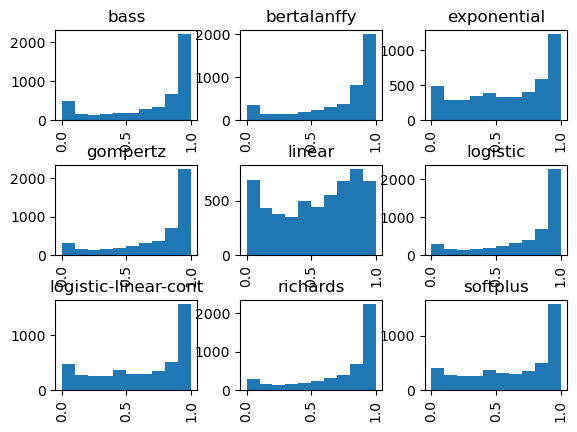

In [12]:
full_table.hist(column='r_squared_masked', by='functional_form')

In [13]:
from scipy import stats

stats.normaltest(full_table['r_squared_masked'].dropna().values)

NormaltestResult(statistic=np.float64(6041.374801061633), pvalue=np.float64(0.0))

pvalue = "low" mean low probability that sample was drawn from a normal distribution

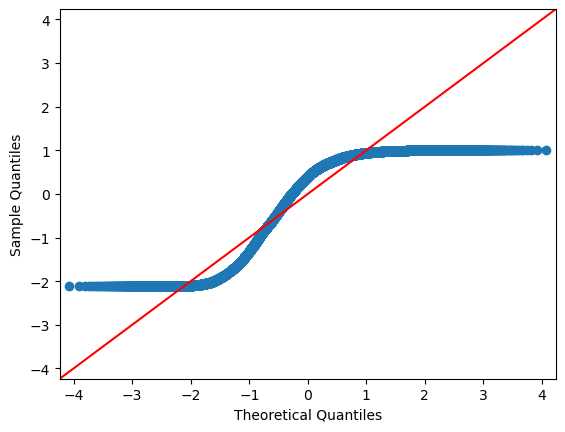

In [14]:
fig = sm.qqplot(full_table['r_squared_masked'].dropna().values, stats.norm, fit=True, line="45")
plt.show()

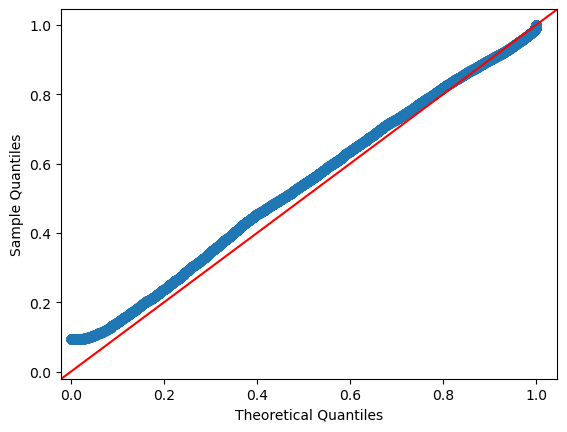

In [15]:
# qqplot of data with fitted beta distribution
fig = sm.qqplot(full_table['r_squared_masked'].dropna().values, stats.beta, fit=True, line="45")
plt.show()

## Relationship between max/mean in country level data and goodness of fit?

In [16]:
full_table['Technology Name'].value_counts().head(20) / 9

Technology Name
Capture Fisheries        210.00
DTP3 Vaccine             194.00
POL3 Vaccine             194.00
DTP1 Vaccine             194.00
MCV1 Vaccine             194.00
Aquaculture Production   182.00
HEPB3 Vaccine            181.00
HIB3 Vaccine             178.00
BCG Vaccine              166.00
Telephones               152.00
Television               151.00
MCV2 Vaccine             138.00
Passenger Cars           136.00
RCV1 Vaccine             134.00
Radio                    129.00
Onshore Wind Energy      124.89
Solar Photovoltaic       124.11
Salt Production          113.00
Crop Harvester           113.00
Railroad                 104.00
Name: count, dtype: float64

<Axes: xlabel='y_max', ylabel='r_squared_masked'>

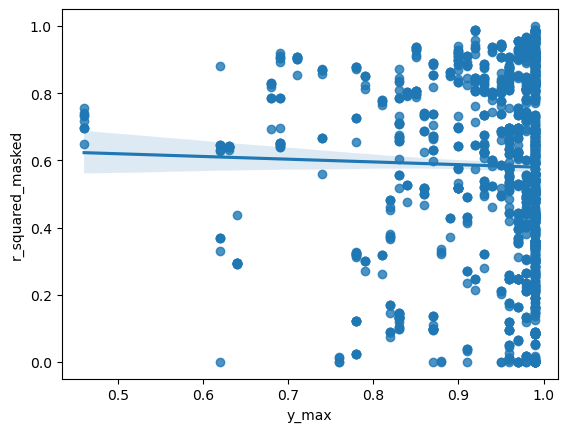

In [17]:
# y_max or y_mean
subset = full_table[full_table['Technology Name'] == 'MCV1 Vaccine']
sns.regplot(data=subset, y='r_squared_masked', x='y_max')

In [18]:
results = smf.ols(formula='r_squared_masked ~ y_max', data=subset).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.018
Date:                Thu, 12 Feb 2026   Prob (F-statistic):              0.313
Time:                        17:13:09   Log-Likelihood:                -233.44
No. Observations:                1596   AIC:                             470.9
Df Residuals:                    1594   BIC:                             481.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6601      0.076      8.722      0.0

<Axes: xlabel='y_mean', ylabel='r_squared_masked'>

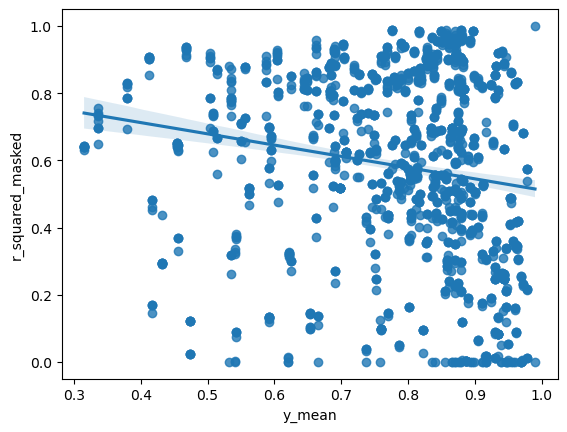

In [19]:
# y_max or y_mean
subset = full_table[full_table['Technology Name'] == 'MCV1 Vaccine']
sns.regplot(data=subset, y='r_squared_masked', x='y_mean')

In [20]:
results = smf.ols(formula='r_squared_masked ~ y_mean', data=subset).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     49.89
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           2.42e-12
Time:                        17:13:10   Log-Likelihood:                -209.36
No. Observations:                1596   AIC:                             422.7
Df Residuals:                    1594   BIC:                             433.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8463      0.038     22.414      0.0

In [21]:
# loop over several technologies with many timeseries
print_res = False
res_dict = {}
techs = full_table['Technology Name'].value_counts().head(50).index

for tech in techs:
    results = smf.ols(formula='r_squared_masked ~ y_max', data=full_table[full_table['Technology Name'] == tech]).fit()
    res_dict[tech] = {'intercept': results.params.iloc[0], 'coeff_y_max': results.params.iloc[1], 'f_pvalue': results.f_pvalue, 'metric_grouped': full_table[full_table['Technology Name'] == tech].iloc[0]['metric_grouped']}
    if print_res:
        print(tech)
        print(results.params)
        print(results.f_pvalue)
        print()

In [22]:
res_df = pd.DataFrame(res_dict).transpose().dropna()
res_df.head()

,intercept,coeff_y_max,f_pvalue,metric_grouped
Capture Fisheries,0.60,0.00,0.00,annual
DTP3 Vaccine,1.02,-0.46,0.00,share
POL3 Vaccine,1.12,-0.60,0.00,share
DTP1 Vaccine,1.26,-0.80,0.00,share
MCV1 Vaccine,0.66,-0.08,0.31,share


array([[<Axes: title={'center': '(annual,)'}>,
        <Axes: title={'center': '(cumulative,)'}>],
       [<Axes: title={'center': '(share,)'}>, <Axes: >]], dtype=object)

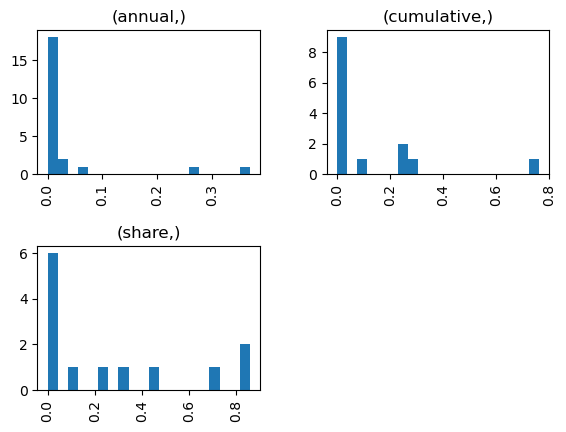

In [23]:
res_df.hist('f_pvalue', by=['metric_grouped'], bins=20)

In [24]:
res_df.groupby('metric_grouped')['coeff_y_max'].mean()

metric_grouped
annual        0.00
cumulative   -0.00
share        -0.35
Name: coeff_y_max, dtype: object

array([[<Axes: title={'center': '(annual,)'}>,
        <Axes: title={'center': '(cumulative,)'}>],
       [<Axes: title={'center': '(share,)'}>, <Axes: >]], dtype=object)

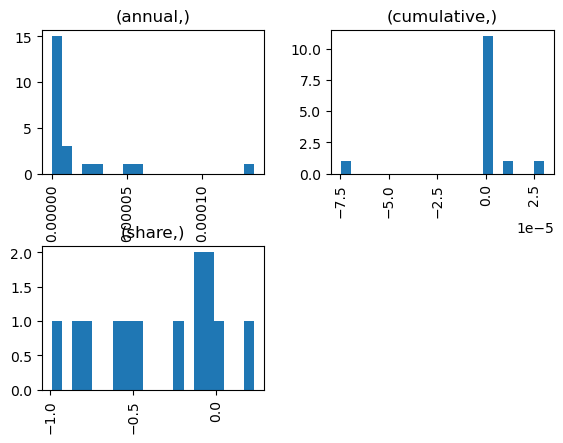

In [25]:
res_df.hist('coeff_y_max', by=['metric_grouped'], bins=20)

# Descriptives of metadata and r2 for regression analysis

In [26]:
for yr_var in ['Year of Invention', 'Year of First Embodiment of Tech', 'FirstCommercialYr', 'Granularity Numerical', 'Material Use Numerical']:
    full_table[yr_var + '_numeric'] = pd.to_numeric(full_table[yr_var], errors='coerce')
    full_table[yr_var + '_numcent'] = full_table[yr_var + '_numeric'] - full_table[yr_var + '_numeric'].mean()

In [27]:
full_table['Need for Customization'] = full_table['Need for Customization'].replace({'Mass-Customized [2]': 'Mass-customized [2]'})

too_long_pat_label = 'General Tagging of New Technological Developments; General Tagging of Cross-Sectional Technologies Spanning over Several Sections of the IPC; Technical Subjects Covered by Former USPC Cross-Reference Art Collections [XRACs] and Digests'
full_table['Patent Category Name'] = full_table['Patent Category Name'].replace({too_long_pat_label: 'General Tagging'})

In [28]:
vars = ['Spatial Scale', 'Material Use Numerical_numcent',
       'Final Material Use', 'Year of Invention_numcent',
       'Year of First Embodiment of Tech_numcent', 'FirstCommercialYr_numcent',
       'Need for Customization', 'Complexity', 'Type of Adopter',
       'Granularity Numerical_numcent', 'Granularity', 'Average lifetime',
       'Technology Lifetime', 'Strict replacement', 'Broad replacement',
       'Feedstock', 'Category Type', 'Patent Category Name', 'metric_grouped']

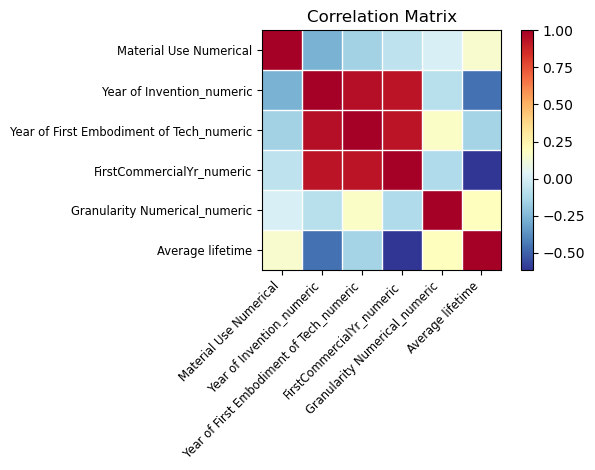

In [29]:
# Correlation between metadata

vars_num = ['Material Use Numerical', 'Year of Invention_numeric',
       'Year of First Embodiment of Tech_numeric', 'FirstCommercialYr_numeric',
       'Granularity Numerical_numeric', 'Average lifetime']

corr_metadata = full_table[vars_num].corr()
fig = smg.plot_corr(corr_metadata, xnames=vars_num)

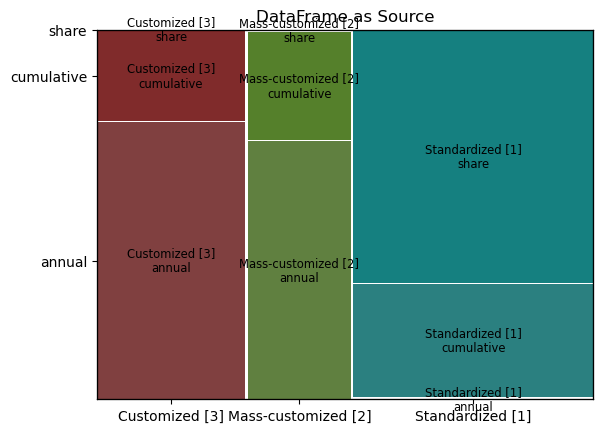

In [30]:
# mosaic plot
from statsmodels.graphics.mosaicplot import mosaic

fig, rects = mosaic(full_table, ['Need for Customization', 'metric_grouped'], title='DataFrame as Source')

## Share of irregular R2 in different categories

In [31]:
tab = full_table.assign(r2_regular=full_table['r_squared_masked'].notna()).groupby('functional_form')['r2_regular'].value_counts().unstack()
tab

r2_regular,False,True
functional_form,,
bass,737,4810
bertalanffy,848,4699
exponential,876,4671
gompertz,753,4794
linear,58,5489
logistic,720,4827
logistic-linear-cont,855,4692
richards,735,4759
softplus,929,4618


Text(0.5, 0, 'Share with 0 < R2 <= 1')

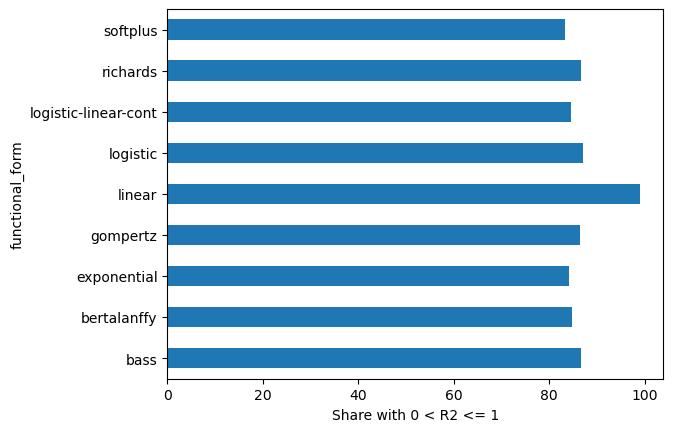

In [32]:
# share of non-regular R2
tab_norm = 100*full_table.assign(r2_regular=full_table['r_squared_masked'].notna()).groupby('functional_form')['r2_regular'].value_counts(normalize=True).unstack()
tab_norm[True].plot.barh()
plt.xlabel('Share with 0 < R2 <= 1')

Spatial Scale
r2_regular      False    True 
Spatial Scale                 
Global            NaN   826.00
National      6511.00 42533.00

Material Use Numerical_numcent
              count  mean   std   min   25%   50%   75%    max
r2_regular                                                    
False       6237.00 -0.72 61.99 -8.38 -8.37 -8.29 -7.31 672.97
True       37552.00  0.12 70.59 -8.38 -8.37 -8.35 -7.77 672.97

Final Material Use
r2_regular           False  True 
Final Material Use               
High Material Use     1882   8270
Low Material Use      3097  21823
Medium Material Use   1517  11895

Year of Invention_numcent
              count  mean   std     min    25%   50%   75%   max
r2_regular                                                      
False       1964.00  5.04 53.52 -209.67  -2.67 36.33 48.33 48.33
True       16143.00 -0.61 47.67 -209.67 -28.67 -2.67 37.33 59.33

Year of First Embodiment of Tech_numcent
             count  mean   std     min    25%   50%   75%  

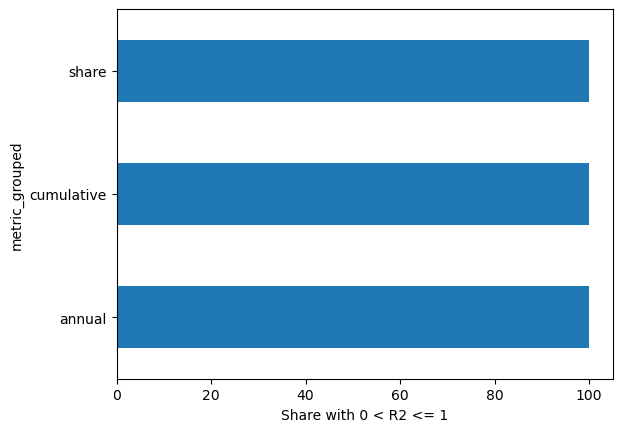

In [33]:
from pandas.api.types import is_numeric_dtype

for var in vars:
    print(var)

    if is_numeric_dtype(full_table[var]):
        comp = full_table.assign(r2_regular=full_table['r_squared_masked'].notna()).groupby('r2_regular')[var].describe()
        print(comp)
    else:
        tab = full_table.assign(r2_regular=full_table['r_squared_masked'].notna()).groupby(var)['r2_regular'].value_counts().unstack()
        print(tab)
        tab_norm = 100*full_table.assign(r2_regular=full_table['r_squared_masked'].notna()).groupby(var)['r2_regular'].value_counts(normalize=True).unstack()
        tab_norm[True].plot.barh()
        plt.xlabel('Share with 0 < R2 <= 1')
    print()

In [34]:
# how often are irregular R2 coocurring within the same timeseries?
r2_irregular = full_table[full_table['r_squared_masked'].isna()]
r2_irregular['technology'].value_counts().value_counts()

count
8    389
1    288
7    201
4     85
3     83
6     82
5     52
9     37
2     15
Name: count, dtype: int64

In [35]:
# check fingerprints

fingerprints_all = ['n', 't_min', 't_max',
       'dt_min', 'dt_max', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first']

for var in fingerprints_all:
    print(var)
    comp = full_table.assign(r2_regular=full_table['r_squared_masked'].notna()).groupby('r2_regular')[var].describe()
    print(comp)
    print()


n
              count  mean   std   min   25%   50%   75%    max
r2_regular                                                    
False       6511.00 29.07 18.20 10.00 17.00 22.00 37.00 149.00
True       43359.00 40.25 26.23 10.00 22.00 37.00 51.00 254.00

t_min
              count    mean   std     min     25%     50%     75%     max
r2_regular                                                               
False       6511.00 1986.96 21.97 1841.00 1981.00 1990.00 2000.00 2013.00
True       43359.00 1971.28 34.86 1720.00 1960.00 1980.00 1993.00 2013.00

t_max
              count    mean   std     min     25%     50%     75%     max
r2_regular                                                               
False       6511.00 2015.56  9.02 1941.00 2011.00 2021.00 2021.00 2022.00
True       43359.00 2012.28 13.80 1861.00 2002.00 2020.00 2021.00 2022.00

dt_min
              count  mean  std  min  25%  50%  75%   max
r2_regular                                              
False       6511.0

/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


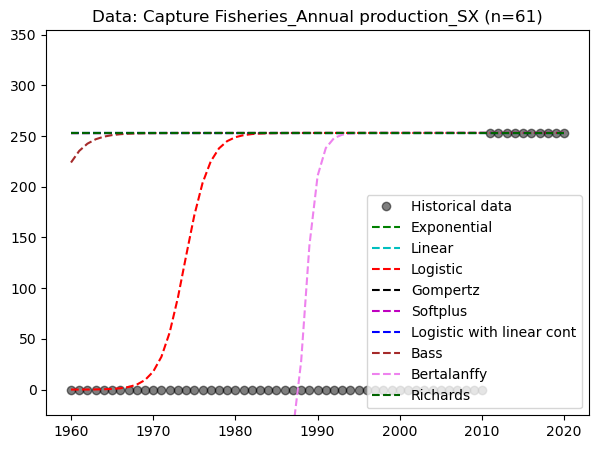

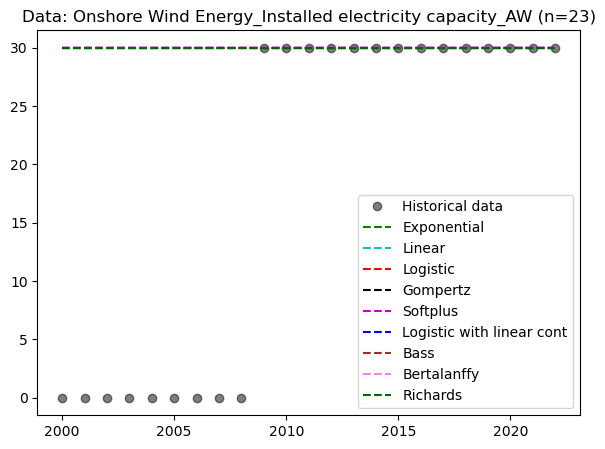

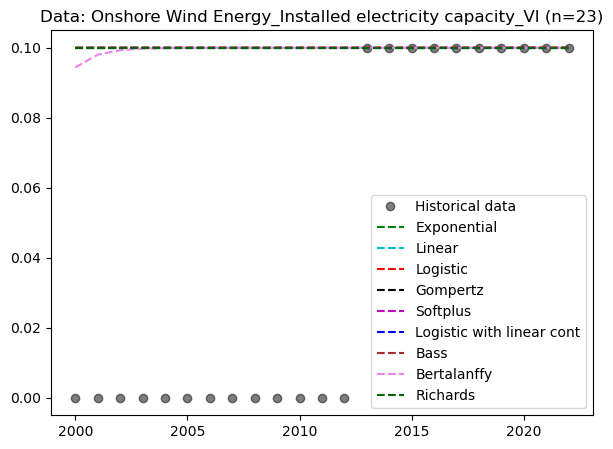

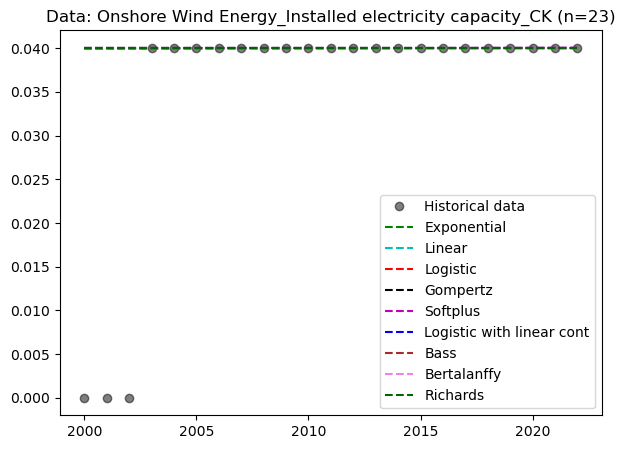

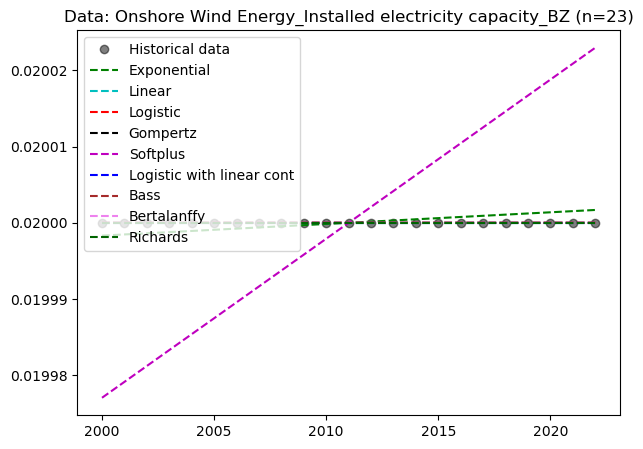

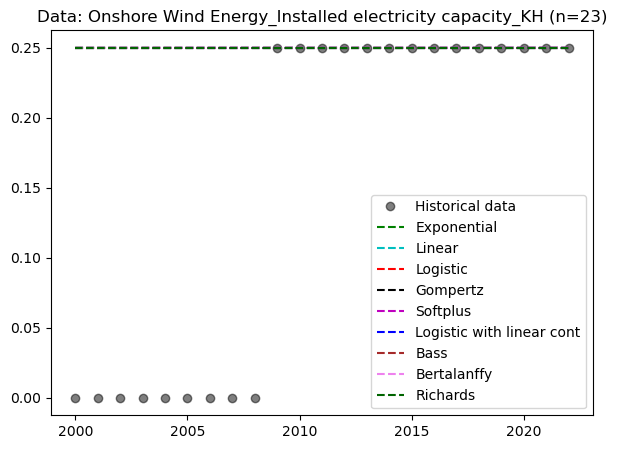

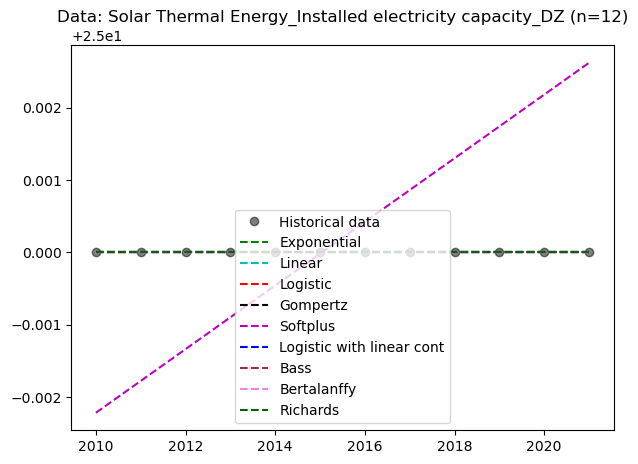

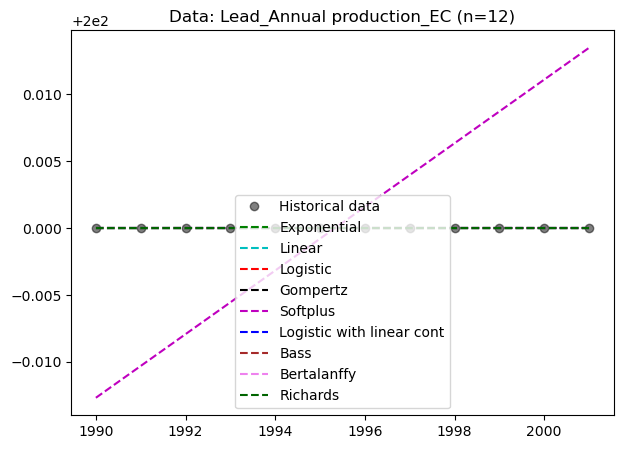

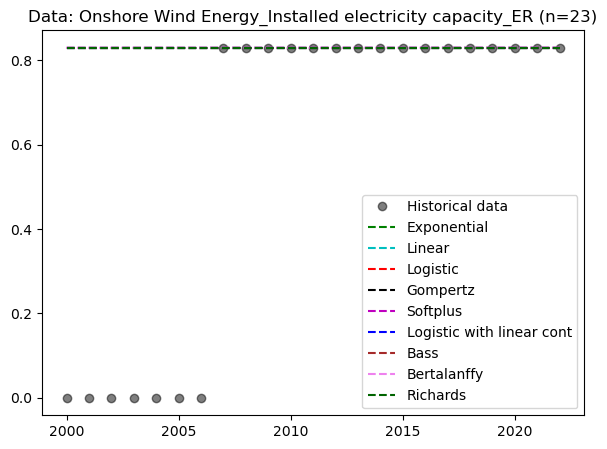

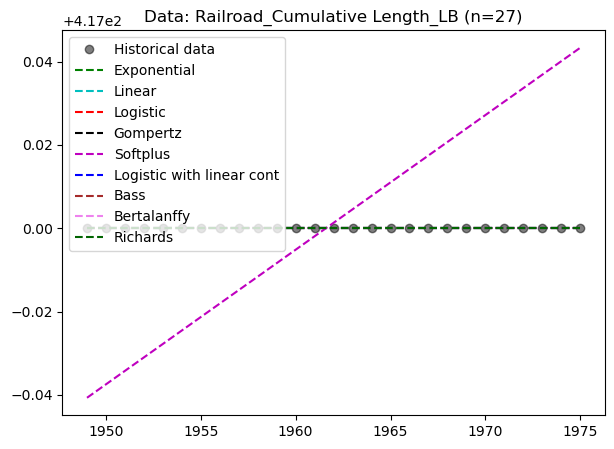

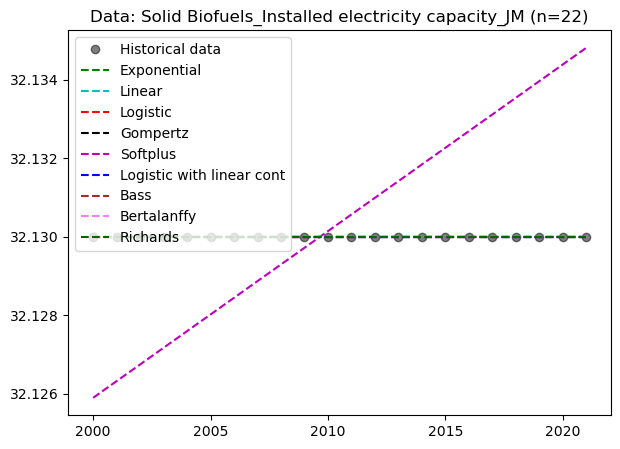

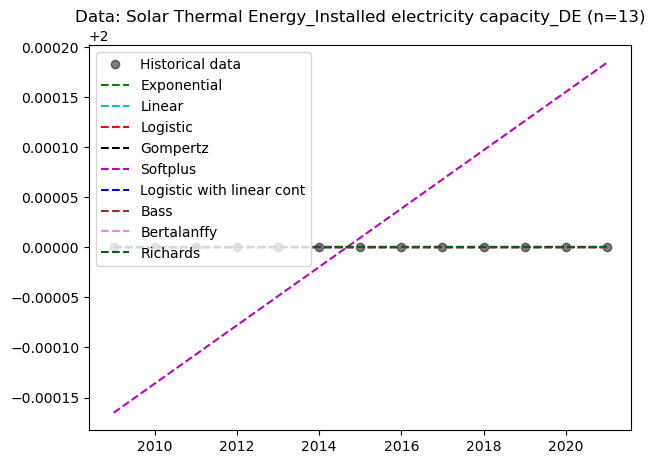

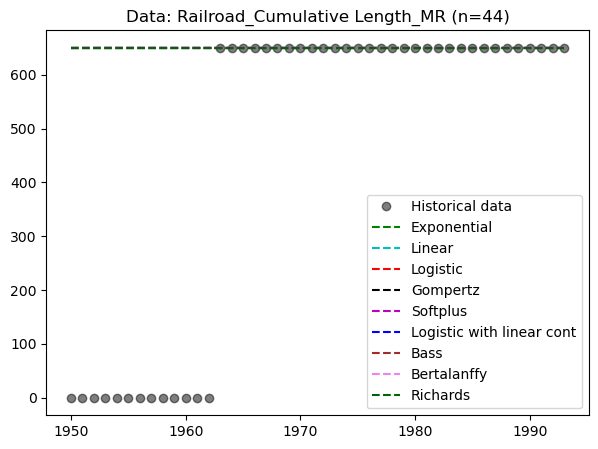

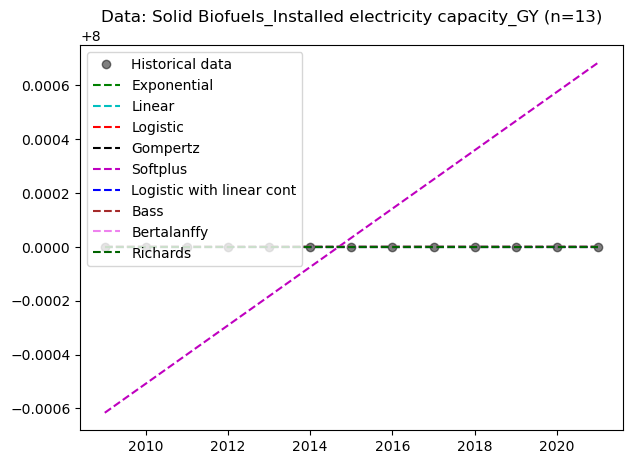

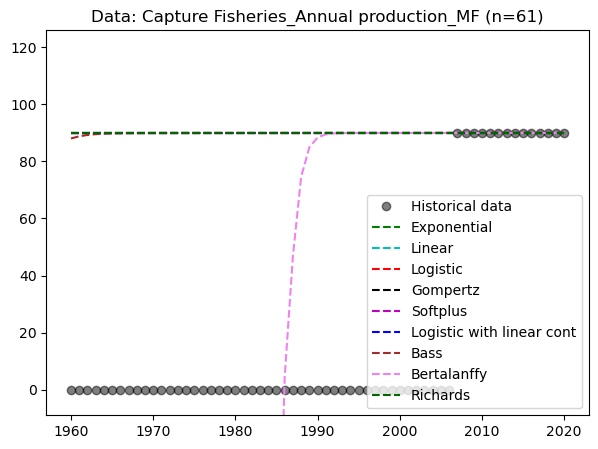

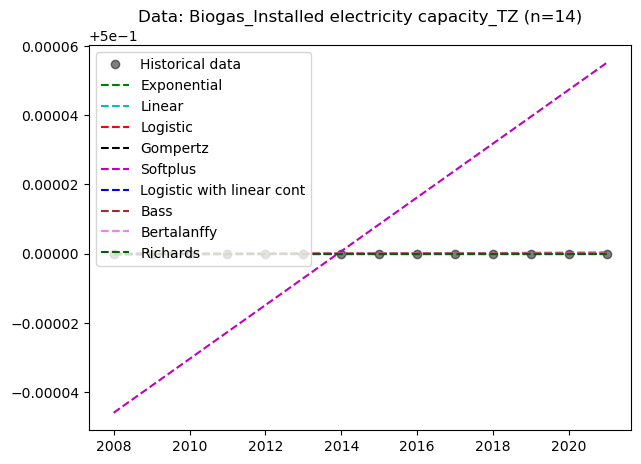

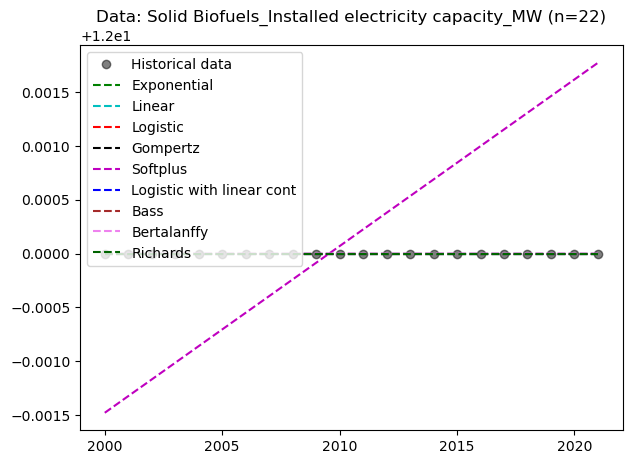

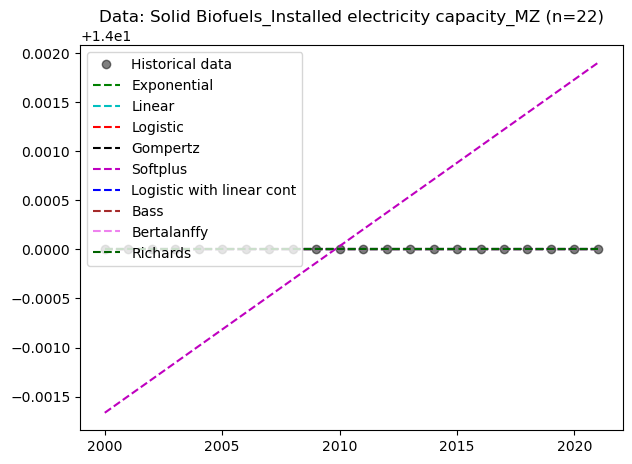

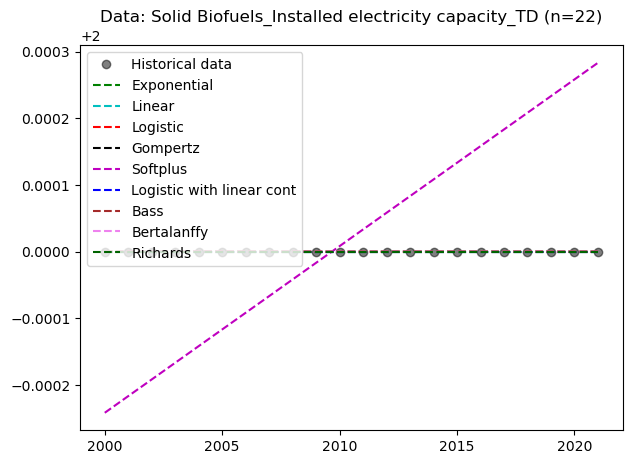

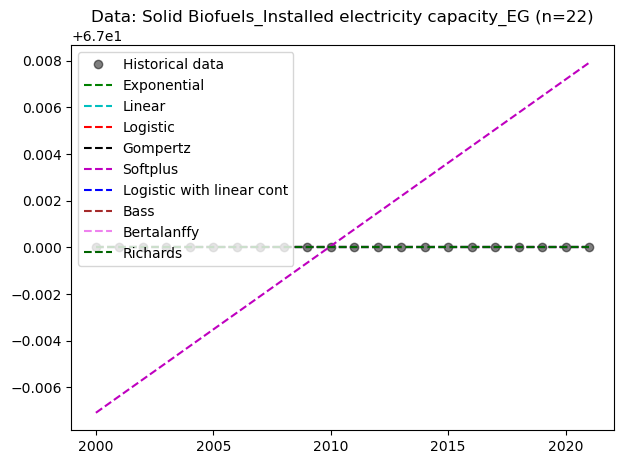

In [36]:
# show some examples where R2 is irregular

from plotting_utils import *

for tech_name in r2_irregular['technology'].value_counts()[0:20].index:

    sl = ts.loc[ts['ID'] == tech_name].iloc[:, 9:].transpose().dropna()
    years = sl.index.to_numpy(dtype='float')
    values = sl.to_numpy(dtype='float')
    sel_fit_results = params[params['technology'] == tech_name]
    #print('r2:', sel_fit_results['r_squared'].values)
    fig_title = f'{tech_name} (n={len(sl)})'
    #fig, ax = plt.subplots()
    #ax.plot(years, values)
    #ax.set_title(fig_title)
    fig = plot_curve_fits(years, values, sel_fit_results.to_dict('records'), tech_name=fig_title) #, verbosity=1)


# Run regressions

In [37]:
from pandas.api.types import is_numeric_dtype

for var in vars:
    print(var)
    if full_table[var].nunique() < 10:
        print(full_table[var].unique())
    else:
        print(full_table[var].unique()[:9])

    if is_numeric_dtype(full_table[var]):
        results = smf.ols(formula=f'r_squared_masked ~ Q("{var}")', data=full_table).fit()
    else:
        results = smf.ols(formula=f'r_squared_masked ~ 0 + Q("{var}")', data=full_table).fit()
    print(results.summary())
    print()

Spatial Scale
['National' 'Global']
                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     440.9
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           2.12e-97
Time:                        17:13:27   Log-Likelihood:                -11938.
No. Observations:               43359   AIC:                         2.388e+04
Df Residuals:                   43357   BIC:                         2.390e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [38]:
## effect of functional form and explanation of outputs
from statsmodels.compat import lzip

results = smf.ols(formula=f'r_squared_masked ~ 0 + functional_form', data=full_table).fit()
print(results.summary())
print()

# tests for normality of residuals
name = ["Jarque-Bera", "Chi^2 two-tail prob.", "Skew", "Kurtosis"]
test = sms.jarque_bera(results.resid)
print("Results of Jarque-Bera test for normality")
print(lzip(name, test))

name = ["Chi^2", "Two-tail probability"]
test = sms.omni_normtest(results.resid)
print("Results of Omni test for normality")
print(lzip(name, test))

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     313.4
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:13:30   Log-Likelihood:                -10938.
No. Observations:               43359   AIC:                         2.189e+04
Df Residuals:                   43350   BIC:                         2.197e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [39]:
# include fixed effect for functional form

r2_all = {}
for var in vars:
    print(var)
    if full_table[var].nunique() < 10:
        print(full_table[var].unique())
    else:
        print(full_table[var].unique()[:9])

    if is_numeric_dtype(full_table[var]):
        results = smf.ols(formula=f'r_squared_masked ~ Q("{var}") + functional_form', data=full_table).fit()
    else:
        results = smf.ols(formula=f'r_squared_masked ~ 0 + Q("{var}") + functional_form', data=full_table).fit()
    print(results.summary())
    print()
    r2_all[var] = {'rsquared': results.rsquared, 'rsquared_adj': results.rsquared_adj}

Spatial Scale
['National' 'Global']
                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     332.6
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:13:31   Log-Likelihood:                -10709.
No. Observations:               43359   AIC:                         2.144e+04
Df Residuals:                   43349   BIC:                         2.153e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [40]:
pd.DataFrame(r2_all).transpose()

,rsquared,rsquared_adj
Spatial Scale,0.06,0.06
Material Use Numerical_numcent,0.06,0.06
Final Material Use,0.09,0.09
Year of Invention_numcent,0.09,0.09
Year of First Embodiment of Tech_numcent,0.11,0.11
FirstCommercialYr_numcent,0.07,0.07
Need for Customization,0.06,0.06
Complexity,0.07,0.07
Type of Adopter,0.10,0.10
Granularity Numerical_numcent,0.08,0.08


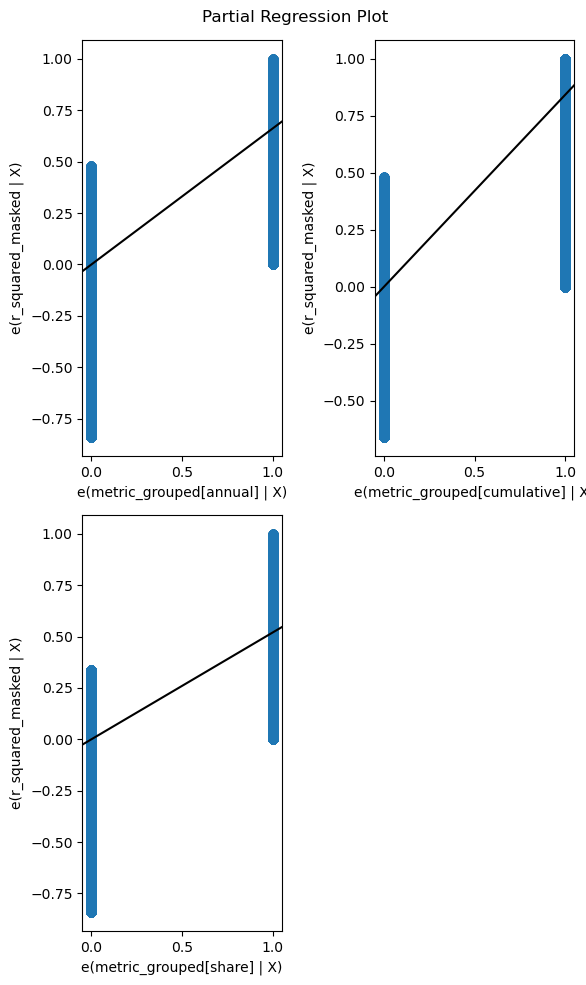

In [41]:
# plot results
results = smf.ols(formula=f'r_squared_masked ~ 0 + metric_grouped', data=full_table).fit()
fig = plt.figure(figsize=(6, 10))
fig = smg.plot_partregress_grid(results, fig=fig)

In [42]:
# include interaction terms for functional form
results = smf.ols(formula=f'r_squared_masked ~ 0 + metric_grouped * functional_form', data=full_table).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     521.9
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:13:43   Log-Likelihood:                -6250.6
No. Observations:               43359   AIC:                         1.256e+04
Df Residuals:                   43332   BIC:                         1.279e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

# All regressors

In [43]:
# run regression with all feasible independent variables (excluding strongly correlated ones on first year)

vars_sel = ['Spatial Scale', 'Material Use Numerical_numcent',
       'Final Material Use', 'FirstCommercialYr_numcent',
       'Need for Customization', 'Complexity', 'Type of Adopter',
       'Granularity', 'Technology Lifetime', 'Strict replacement', 'Broad replacement',
       'Feedstock', 'Category Type', 'Patent Category Name', 'metric_grouped']
# 'Average lifetime', # excluded because missing values for many technologies

full_table[vars_sel].count()

Spatial Scale                     49870
Material Use Numerical_numcent    43789
Final Material Use                48484
FirstCommercialYr_numcent         43646
Need for Customization            48574
Complexity                        48574
Type of Adopter                   48574
Granularity                       48574
Technology Lifetime               46900
Strict replacement                48574
Broad replacement                 48574
Feedstock                         47713
Category Type                     48574
Patent Category Name              48574
metric_grouped                    49870
dtype: int64

In [44]:
for var in vars_sel:
    print(var)
    if full_table[var].nunique() < 10:
        print(full_table[var].unique())
    else:
        print(full_table[var].unique()[:9], "...")
    print("non na:", len(full_table[var].dropna()))

Spatial Scale
['National' 'Global']
non na: 49870
Material Use Numerical_numcent
[-8.34648793 -8.21854343 -8.29391863 -8.34728761 -8.34546193         nan
 -8.37498552 -7.89607992 -6.18631501] ...
non na: 43789
Final Material Use
['Low Material Use' 'Medium Material Use' 'High Material Use' nan]
non na: 48484
FirstCommercialYr_numcent
[          nan  -90.80745085   -5.80745085  -70.80745085  -85.80745085
  -64.80745085 -172.80745085  -61.80745085  -54.80745085] ...
non na: 43646
Need for Customization
['Customized [3]' 'Mass-customized [2]' 'Standardized [1]' nan]
non na: 48574
Complexity
['Design-Intensive [2]' 'Simple [1]' 'Complex [3]' nan]
non na: 48574
Type of Adopter
['Firms [1]' 'Individuals [2]' 'Both [3]' nan]
non na: 48574
Granularity
['Low' 'High' 'Medium' nan]
non na: 48574
Technology Lifetime
['Decades' 'Years' nan 'Months']
non na: 46900
Strict replacement
['No' 'Yes' nan]
non na: 48574
Broad replacement
['Yes' 'No' nan]
non na: 48574
Feedstock
['No' 'Yes' nan]
non na: 477

In [45]:
len(full_table[vars_sel + ['r_squared_masked']].dropna())

32746

In [46]:
len(full_table['r_squared_masked'].dropna())

43359

In [47]:
# ols with all regressors
formula_all = 'r_squared_masked ~ 0 + functional_form + ' + ' + '.join([f'Q("{var}")' for var in vars_sel])
results = smf.ols(formula=formula_all, data=full_table).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     377.6
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:13:45   Log-Likelihood:                -3512.8
No. Observations:               32746   AIC:                             7112.
Df Residuals:                   32703   BIC:                             7473.
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                                                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [48]:
# ols with all regressors but without functional form
formula_all = 'r_squared_masked ~ ' + ' + '.join([f'Q("{var}")' for var in vars_sel])
results = smf.ols(formula=formula_all, data=full_table).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     345.1
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:13:47   Log-Likelihood:                -4966.9
No. Observations:               32746   AIC:                         1.000e+04
Df Residuals:                   32711   BIC:                         1.030e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [49]:
# ANOVA table
table = sm.stats.anova_lm(results, typ=2)
print(table)

                                     sum_sq       df      F  PR(>F)
Q("Spatial Scale")                    18.14     1.00 228.52    0.00
Q("Final Material Use")                0.36     2.00   2.28    0.10
Q("Need for Customization")            3.84     2.00  24.18    0.00
Q("Complexity")                        0.19     2.00   1.18    0.31
Q("Type of Adopter")                   2.89     2.00  18.20    0.00
Q("Granularity")                       0.55     2.00   3.46    0.03
Q("Technology Lifetime")               9.06     2.00  57.09    0.00
Q("Strict replacement")                0.12     1.00   1.56    0.21
Q("Broad replacement")                 0.23     1.00   2.84    0.09
Q("Feedstock")                         0.32     1.00   4.01    0.05
Q("Category Type")                    26.68    10.00  33.61    0.00
Q("Patent Category Name")             22.51     8.00  35.45    0.00
Q("metric_grouped")                    6.05     2.00  38.09    0.00
Q("Material Use Numerical_numcent")    6.68     

/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '
/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7
  warnings.warn('covariance of constraints does not have full '


In [50]:
# generalized linear model
formula_all = 'r_squared_masked ~ 0 + functional_form + ' + ' + '.join([f'Q("{var}")' for var in vars_sel])
results = smf.glm(formula=formula_all, data=full_table).fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       r_squared_masked   No. Observations:                32746
Model:                            GLM   Df Residuals:                    32703
Model Family:                Gaussian   Df Model:                           42
Link Function:               Identity   Scale:                        0.072656
Method:                          IRLS   Log-Likelihood:                -3512.8
Date:                Thu, 12 Feb 2026   Deviance:                       2376.1
Time:                        17:13:50   Pearson chi2:                 2.38e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3838
Covariance Type:            nonrobust                                         
                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [51]:
# ols with all regressors on adjusted r2
formula_all = 'adj_r_squared_masked ~ 0 + functional_form + ' + ' + '.join([f'Q("{var}")' for var in vars_sel])
results = smf.ols(formula=formula_all, data=full_table).fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     adj_r_squared_masked   R-squared:                       0.350
Model:                              OLS   Adj. R-squared:                  0.349
Method:                   Least Squares   F-statistic:                     371.4
Date:                  Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                          17:13:52   Log-Likelihood:                 385.76
No. Observations:                 29057   AIC:                            -685.5
Df Residuals:                     29014   BIC:                            -329.6
Df Model:                            42                                         
Covariance Type:              nonrobust                                         
                                                                                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

In [52]:
from statsmodels.stats.outliers_influence import OLSInfluence

# OLSInfluence(results).plot_influence()
# OLSInfluence(results).plot_index()

## Test mixed effect model

In [53]:

# https://www.statsmodels.org/stable/examples/notebooks/generated/mixed_lm_example.html
filtered_df = full_table[['metric_grouped', 'functional_form', 'r_squared_masked', 'technology']].dropna()
mdf = smf.mixedlm(formula=f'r_squared_masked ~ metric_grouped + functional_form', data=filtered_df, groups=filtered_df["technology"]).fit()
print(mdf.summary())

                       Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        r_squared_masked
No. Observations:        43359          Method:                    REML            
No. Groups:              5510           Scale:                     0.0156          
Min. group size:         1              Log-Likelihood:            18910.8803      
Max. group size:         9              Converged:                 Yes             
Mean group size:         7.9                                                       
-----------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                0.663    0.006 103.503 0.000  0.651  0.676
metric_grouped[T.cumulative]             0.207    0.009  22.572 0.000  0.189  0.225
metric_grouped[

# Regression on growth parameter

In [54]:
# Check whether we can reproduce some of Jenna's findings for the growth parameters 'b'

formula_all = 'b ~ functional_form + ' + ' + '.join([f'Q("{var}")' for var in vars_sel])
results = smf.ols(formula=formula_all, data=full_table[full_table['r_squared_masked'].notna()]).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      b   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     10.62
Date:                Thu, 12 Feb 2026   Prob (F-statistic):           2.11e-68
Time:                        17:14:04   Log-Likelihood:            -4.6480e+05
No. Observations:               32746   AIC:                         9.297e+05
Df Residuals:                   32703   BIC:                         9.300e+05
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                                                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [55]:
# use logged growth parameter
formula_all = 'np.log(b) ~ functional_form + ' + ' + '.join([f'Q("{var}")' for var in vars_sel])
results = smf.ols(formula=formula_all, data=full_table[full_table['r_squared_masked'].notna()]).fit()
print(results.summary())

/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            OLS Regression Results                            
Dep. Variable:              np.log(b)   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     99.57
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:14:06   Log-Likelihood:                -98420.
No. Observations:               31988   AIC:                         1.969e+05
Df Residuals:                   31945   BIC:                         1.973e+05
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                                                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [56]:
# use logged growth parameter

filtered_df = full_table[full_table['r_squared_masked'].notna() & (full_table['r_squared_masked'] > 0.8)]
formula_all = 'np.log(b) ~ functional_form + ' + ' + '.join([f'Q("{var}")' for var in vars_sel])
results = smf.ols(formula=formula_all, data=filtered_df).fit()
print(results.summary())

/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            OLS Regression Results                            
Dep. Variable:              np.log(b)   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     103.7
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:14:07   Log-Likelihood:                -43191.
No. Observations:               15041   AIC:                         8.647e+04
Df Residuals:                   14998   BIC:                         8.680e+04
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                                                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

/home/finn/miniconda3/envs/datenv2/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

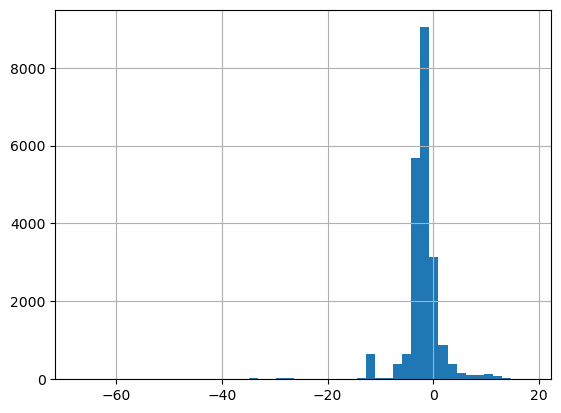

In [57]:
np.log(filtered_df['b']).hist(bins=50)

# Regressions with timeseries fingerprints

37


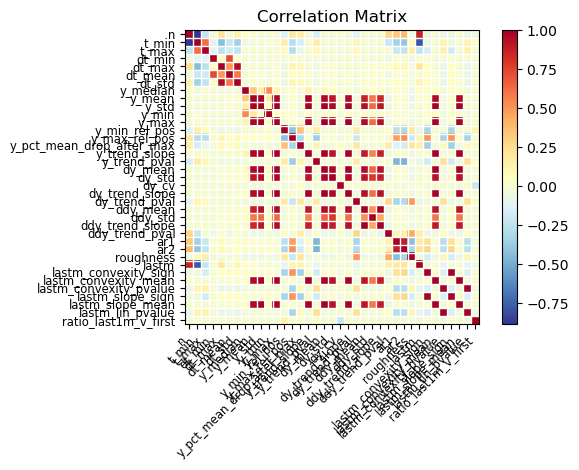

In [58]:
fingerprints_all = ['n', 't_min', 't_max',
       'dt_min', 'dt_max', 'dt_mean', 'dt_std', 'y_median', 'y_mean', 'y_std',
       'y_min', 'y_max', 'y_min_rel_pos', 'y_max_rel_pos',
       'y_pct_mean_drop_after_max', 'y_trend_slope', 'y_trend_pval', 'dy_mean',
       'dy_std', 'dy_cv', 'dy_trend_slope', 'dy_trend_pval', 'ddy_mean',
       'ddy_std', 'ddy_trend_slope', 'ddy_trend_pval', 'ar1', 'ar2',
       'roughness', 'lastm', 'lastm_convexity_sign', 'lastm_convexity_mean',
       'lastm_convexity_pvalue', 'lastm_slope_sign', 'lastm_slope_mean',
       'lastm_lin_pvalue', 'ratio_last1m_v_first']
print(len(fingerprints_all))

corr_fp = full_table[fingerprints_all].corr()

fig = smg.plot_corr(corr_fp, xnames=fingerprints_all)

In [ ]:
# check co-linearity by looking at eigenvalues of the correlation matrix
# https://stackoverflow.com/questions/25676145/capturing-high-multi-collinearity-in-statsmodels
w, v = np.linalg.eig(corr_fp)        # eigen values & eigen vectors
w

array([1.09451137e+01, 4.82801797e+00, 3.11200983e+00, 2.33727435e+00,
       1.90817890e+00, 1.64926985e+00, 1.57618394e+00, 1.30929482e+00,
       1.22839691e+00, 1.20238221e+00, 9.64420320e-01, 7.89623788e-01,
       7.57861557e-01, 7.27904388e-01, 7.09710941e-01, 5.64472366e-01,
       5.41084778e-01, 4.82209921e-01, 4.06964704e-01, 2.74993446e-01,
       2.44541309e-01, 1.55161529e-01, 1.30035239e-01, 9.68902840e-02,
       3.20457227e-02, 1.54306094e-02, 6.12222441e-03, 2.57030132e-03,
       1.25074499e-03, 2.59684689e-04, 1.37488901e-04, 1.17210661e-04,
       3.33370644e-05, 2.17201968e-05, 1.31002989e-05, 7.54640556e-07,
       6.32401213e-09])

In [86]:
# calculate variance inflation factor (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

indep_vars = full_table[fingerprints_all].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = indep_vars.columns

vif_data["VIF"] = [variance_inflation_factor(indep_vars.values, i)
                          for i in range(len(indep_vars.columns))]

In [89]:
vif_data.sort_values(by='VIF')

,feature,VIF
19,dy_cv,1.05
36,ratio_last1m_v_first,1.07
16,y_trend_pval,1.43
14,y_pct_mean_drop_after_max,1.44
12,y_min_rel_pos,1.47
21,dy_trend_pval,1.63
25,ddy_trend_pval,1.74
13,y_max_rel_pos,2.00
28,roughness,2.38
29,lastm,4.68


In [93]:
reduced_vars = vif_data.sort_values(by='VIF').head(19)['feature']

In [59]:
# ols with all fingerprints as regressors

fingerprints = fingerprints_all

formula_all = 'r_squared_masked ~ 0 + functional_form + ' + ' + '.join(fingerprints)
results = smf.ols(formula=formula_all, data=full_table).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     2065.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:15:12   Log-Likelihood:                 13228.
No. Observations:               42728   AIC:                        -2.636e+04
Df Residuals:                   42682   BIC:                        -2.596e+04
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [ ]:
standardized_data = full_table[['r_squared_masked'] + fingerprints_all].replace([np.inf, -np.inf], np.nan).apply(stats.zscore, nan_policy='omit')
standardized_data = pd.merge(full_table[['functional_form']], standardized_data, left_index=True, right_index=True)

In [76]:
# the same with standardized data
formula_all = 'r_squared_masked ~ 0 + functional_form + ' + ' + '.join(fingerprints)
results = smf.ols(formula=formula_all, data=standardized_data).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     2065.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:31:46   Log-Likelihood:                -35421.
No. Observations:               42728   AIC:                         7.093e+04
Df Residuals:                   42682   BIC:                         7.133e+04
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [80]:
# without functional form
formula_all = 'r_squared_masked ~ ' + ' + '.join(fingerprints)
results = smf.ols(formula=formula_all, data=standardized_data).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     2031.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:33:06   Log-Likelihood:                -38430.
No. Observations:               42728   AIC:                         7.694e+04
Df Residuals:                   42690   BIC:                         7.727e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [94]:
formula_all = 'r_squared_masked ~ ' + ' + '.join(reduced_vars)
results = smf.ols(formula=formula_all, data=standardized_data).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.632
Method:                 Least Squares   F-statistic:                     3864.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:04:23   Log-Likelihood:                -38748.
No. Observations:               42728   AIC:                         7.754e+04
Df Residuals:                   42708   BIC:                         7.771e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [97]:
# reduce number of predictors to the most relevant ones
most_rel_fingerprints = np.abs(results.params).drop('Intercept').sort_values(ascending=False).head(5).index

formula_all = 'r_squared_masked ~ ' + ' + '.join(most_rel_fingerprints)
results = smf.ols(formula=formula_all, data=standardized_data).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       r_squared_masked   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                 1.368e+04
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:09:58   Log-Likelihood:                -40813.
No. Observations:               43244   AIC:                         8.164e+04
Df Residuals:                   43238   BIC:                         8.169e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

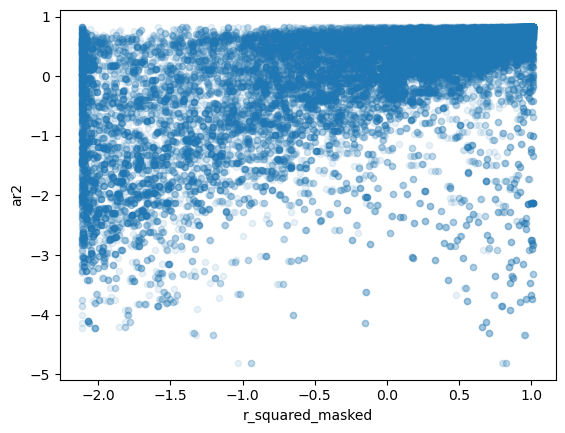

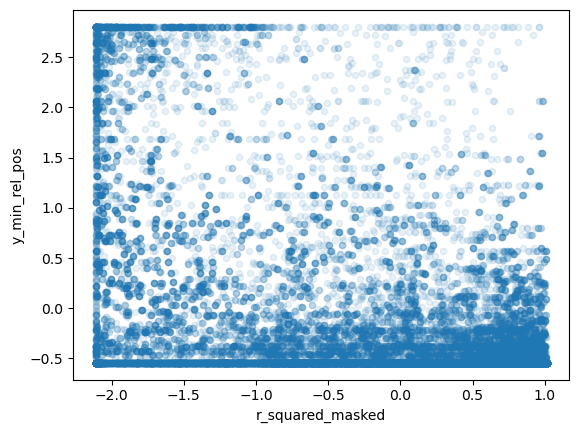

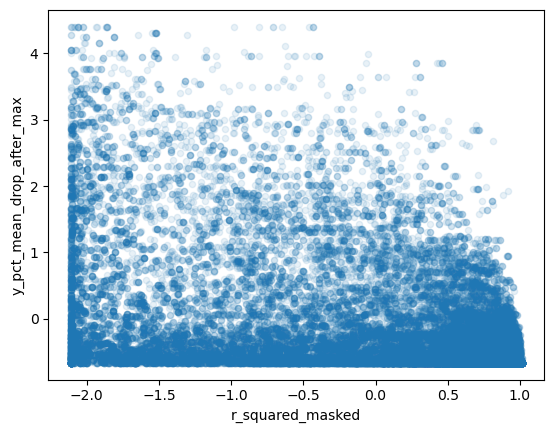

In [103]:
for var in ['ar2', 'y_min_rel_pos', 'y_pct_mean_drop_after_max']:
    standardized_data.plot.scatter(x='r_squared_masked', y=var, alpha=0.1)

In [81]:
# try to predict goodness of fit rank

full_table['BIC_rank'] = full_table.groupby('technology')['BIC'].rank(method='min')
full_table['MCp_rank'] = full_table.groupby('technology')['MCp'].rank(method='min')
full_table['aRS_rank'] = full_table.groupby('technology')['adj_r_squared'].rank(method='min', ascending=False)

standardized_data = full_table[fingerprints_all].replace([np.inf, -np.inf], np.nan).apply(stats.zscore, nan_policy='omit')
standardized_data = pd.merge(full_table[['BIC_rank', 'MCp_rank', 'aRS_rank', 'functional_form']], standardized_data, left_index=True, right_index=True)

formula_all = 'BIC_rank ~ ' + ' + '.join(fingerprints)
results = smf.ols(formula=formula_all, data=standardized_data).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               BIC_rank   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.03693
Date:                 Mi, 28 Mai 2025   Prob (F-statistic):               1.00
Time:                        22:18:14   Log-Likelihood:            -1.1499e+05
No. Observations:               48574   AIC:                         2.301e+05
Df Residuals:                   48536   BIC:                         2.304e+05
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [82]:
formula_red = 'aRS_rank ~ 0 + lastm_convexity_mean:functional_form + lastm_slope_mean:functional_form'
results = smf.ols(formula=formula_red, data=standardized_data).fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:               aRS_rank   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.000
Method:                 Least Squares   F-statistic:                             0.6934
Date:                 Mi, 28 Mai 2025   Prob (F-statistic):                       0.821
Time:                        22:18:15   Log-Likelihood:                     -1.5662e+05
No. Observations:               49834   AIC:                                  3.133e+05
Df Residuals:                   49816   BIC:                                  3.134e+05
Df Model:                          18                                                  
Covariance Type:            nonrobust                                                  
                                                                 coef    std err          t      P>|t|      [0.025      

## Notes

Models not significant and R2 = 0, tested for different ranks

In [83]:

formula_all = 'aRS_rank ~ ' + ' + '.join(fingerprints)
results = smf.ols(formula=formula_all, data=standardized_data[standardized_data['functional_form'] == 'exponential']).fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:               aRS_rank   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     53.43
Date:                 Mi, 28 Mai 2025   Prob (F-statistic):               0.00
Time:                        22:18:15   Log-Likelihood:                -12439.
No. Observations:                5403   AIC:                         2.495e+04
Df Residuals:                    5365   BIC:                         2.520e+04
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             